# Fairness Exercise

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import metrics
from sklearn import linear_model
from sklearn import ensemble
from sklearn import tree
from sklearn import svm
from sklearn import cluster
from sklearn import decomposition
from sklearn import pipeline
from sklearn import compose

Nell'esercizio 5 non bisogna riallenare il modello una volta attuata la feature permutation.
Nell'esercizio 6 si, perché ne stiamo togliendo una, e il modello non è più lo stesso. Inoltre il modello va allenato sulle stesse feature su cui viene testato.

## Es. 1

In [2]:
df = pd.read_csv('hiring_decisions.csv', sep=',')
df

,id,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,0,26,1,2,0,3,26.783828,48,78,91,1,1
1,1,39,1,4,12,3,25.862694,35,68,80,2,1
2,2,48,0,2,3,2,9.920805,20,67,13,2,0
3,3,34,1,2,5,2,6.407751,36,27,70,3,0
4,4,30,0,1,6,1,43.105343,23,52,85,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1495,48,0,2,3,4,9.183783,66,3,80,3,1
1496,1496,27,1,2,10,3,14.847731,43,97,7,2,0
1497,1497,24,1,1,1,2,4.289911,31,91,58,1,1
1498,1498,48,0,2,4,4,36.299263,9,37,44,2,1


In [3]:
df.isnull().sum()

id                     0
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

Dataset è completo, ovvero no valori nulli.

In [4]:
df[['HiringDecision']].value_counts()

HiringDecision
0                 1035
1                  465
Name: count, dtype: int64

Dataset non bilanciato rispetto alla classe da predire.

## Es. 2

In [5]:
df.isnull().sum()

id                     0
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

Tolgo l'id per evitare overfitting (e ovviamente HiringDecision perché è la label).

In [6]:
X = df.drop(['id', 'HiringDecision'], axis=1)
y = df['HiringDecision']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

Con *stratify* gli passiamo la colonna delle label da usare per la stratificazione, in modo da ricreare la stessa distribuzione nei vari split.

## Es. 3

In [7]:
coltran = compose.ColumnTransformer(transformers=[("std", preprocessing.StandardScaler(), ['Age', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies',
                                                                                            'DistanceFromCompany', 'InterviewScore', 'SkillScore',
                                                                                            'PersonalityScore', 'RecruitmentStrategy'])],
                                    remainder='passthrough')

In [8]:
X_train = coltran.fit_transform(X_train)
X_test = coltran.transform(X_test)

In [9]:
X_train, X_test

(array([[-0.53268273, -0.22402011,  0.48679567, ...,  0.04455647,
          1.59426141,  0.        ],
        [-0.31626234, -0.22402011,  1.55892787, ..., -0.09165556,
          0.13846264,  0.        ],
        [-0.09984194,  0.93204697,  0.70122211, ..., -0.53434467,
          0.13846264,  1.        ],
        ...,
        [-1.18194392,  0.93204697, -1.01418941, ..., -1.58998792,
          0.13846264,  1.        ],
        [-1.29015411, -0.22402011,  0.48679567, ...,  0.01050346,
          0.13846264,  1.        ],
        [-0.74910313,  2.08811406, -0.58533653, ...,  0.28292753,
          0.13846264,  1.        ]]),
 array([[-0.09984194, -0.22402011,  1.34450143, ..., -1.35161686,
          0.13846264,  1.        ],
        [-0.31626234, -0.22402011,  1.13007499, ...,  1.30451777,
          0.13846264,  1.        ],
        [ 0.98226003, -0.22402011,  0.48679567, ...,  0.31698053,
         -1.31733614,  1.        ],
        ...,
        [-1.39836431,  0.93204697, -1.65746873, ...,  

In [10]:
coltran.get_feature_names_out().tolist()

['std__Age',
 'std__EducationLevel',
 'std__ExperienceYears',
 'std__PreviousCompanies',
 'std__DistanceFromCompany',
 'std__InterviewScore',
 'std__SkillScore',
 'std__PersonalityScore',
 'std__RecruitmentStrategy',
 'remainder__Gender']

In [11]:
# Recuperare i nomi delle colonne trasformate
transformed_features = coltran.named_transformers_['std'].get_feature_names_out()
transformed_features

array(['Age', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies',
       'DistanceFromCompany', 'InterviewScore', 'SkillScore',
       'PersonalityScore', 'RecruitmentStrategy'], dtype=object)

In [12]:
transformed_features = list(transformed_features)

In [13]:
output_cols = transformed_features + ['Gender']
output_cols

['Age',
 'EducationLevel',
 'ExperienceYears',
 'PreviousCompanies',
 'DistanceFromCompany',
 'InterviewScore',
 'SkillScore',
 'PersonalityScore',
 'RecruitmentStrategy',
 'Gender']

In [14]:
# Ricreiamo i dataframe (ora con i valori scalati)
X_train = pd.DataFrame(X_train, columns=output_cols)
X_test = pd.DataFrame(X_test, columns=output_cols)


In [15]:
X_train

,Age,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,Gender
0,-0.532683,-0.224020,0.486796,1.416428,0.070965,-0.569478,0.012749,0.044556,1.594261,0.0
1,-0.316262,-0.224020,1.558928,0.707269,0.015775,-0.918177,1.508230,-0.091656,0.138463,0.0
2,-0.099842,0.932047,0.701222,-0.001891,1.739585,1.278622,-1.006896,-0.534345,0.138463,1.0
3,-1.181944,-0.224020,-1.657469,1.416428,0.842912,0.406877,-1.618684,0.282928,0.138463,0.0
4,1.306891,-0.224020,-1.014189,-0.711051,-0.018372,-1.406354,-0.565050,0.248875,-1.317336,0.0
...,...,...,...,...,...,...,...,...,...,...
1120,1.631521,0.932047,0.701222,-1.420210,-1.280298,-1.162265,0.352631,0.248875,0.138463,1.0
1121,-0.099842,-1.380087,0.486796,0.707269,-0.099183,1.383231,1.576206,-0.806769,0.138463,0.0
1122,-1.181944,0.932047,-1.014189,1.416428,1.541152,0.197658,0.964419,-1.589988,0.138463,1.0
1123,-1.290154,-0.224020,0.486796,0.707269,1.686056,0.476616,0.862454,0.010503,0.138463,1.0


In [16]:
X_test

,Age,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,Gender
0,-0.099842,-0.224020,1.344501,-1.420210,-1.357843,0.755575,-0.870944,-1.351617,0.138463,1.0
1,-0.316262,-0.224020,1.130075,-1.420210,-0.237907,0.895054,-0.497074,1.304518,0.138463,1.0
2,0.982260,-0.224020,0.486796,-1.420210,-1.217997,-0.429999,1.508230,0.316981,-1.317336,1.0
3,-1.290154,-0.224020,-1.443042,-0.001891,-0.735655,-0.743827,1.202336,-0.432186,0.138463,0.0
4,1.306891,-0.224020,-0.156484,-0.711051,-0.966402,1.418101,-1.312790,1.236412,1.594261,1.0
...,...,...,...,...,...,...,...,...,...,...
370,0.224789,2.088114,-1.014189,-1.420210,1.359769,-1.720182,0.114714,0.623458,-1.317336,0.0
371,-0.316262,0.932047,-0.370910,-0.001891,0.356630,-1.371484,1.168348,-0.738663,-1.317336,1.0
372,-1.398364,0.932047,-1.657469,-0.711051,-0.853889,0.441746,-1.482731,0.453193,0.138463,0.0
373,0.441209,0.932047,0.272369,-0.001891,0.650623,0.511486,1.202336,-1.113246,1.594261,0.0


### Modello e valutazione performance

In [17]:
model = linear_model.SGDClassifier(random_state=123)
model.fit(X_train, y_train)

SGDClassifier(random_state=123)

In [18]:
trainpred = model.predict(X_train)
testpred = model.predict(X_test)

In [19]:
print(f"F1-score on train {metrics.f1_score(y_train, trainpred)}")
print(f"F1-score on test {metrics.f1_score(y_test, testpred)}")

F1-score on train 0.7370030581039755
F1-score on test 0.7186147186147186


In [20]:
print("Confusion matrix on train")
print(metrics.confusion_matrix(y_train, trainpred))
print("Confusion matrix on test")
print(metrics.confusion_matrix(y_test, testpred))

Confusion matrix on train
[[712  64]
 [108 241]]
Confusion matrix on test
[[227  32]
 [ 33  83]]


In [21]:
model.feature_names_in_

array(['Age', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies',
       'DistanceFromCompany', 'InterviewScore', 'SkillScore',
       'PersonalityScore', 'RecruitmentStrategy', 'Gender'], dtype=object)

In [22]:
model.coef_

array([[ 0.6708708 ,  1.22738944,  0.8520273 ,  0.13260799, -0.53238017,
         0.86924477,  0.84191251,  0.08581707, -3.31732717, -0.96854176]])

## Es. 4

In [23]:
X_test['pred'] = testpred

In [24]:
uomo = X_test[X_test['Gender']==0]
donna = X_test[X_test['Gender']==1]

prob_uomo = uomo[uomo['pred']==0].shape[0] / uomo.shape[0]
prob_donna = donna[donna['pred']==0].shape[0] / donna.shape[0]

print('Probabilità che un uomo non sia assunto: {}'.format(prob_uomo))
print('Probabilità che una donna non sia assunta: {}'.format(prob_donna))

Probabilità che un uomo non sia assunto: 0.6842105263157895
Probabilità che una donna non sia assunta: 0.7027027027027027


In [25]:
X_test['real'] = y_test.values

print('F1-score sugli uomini: {}'.format(metrics.f1_score(X_test[X_test['Gender']==0]['real'], uomo['pred'])))
print('F1-score sulle donne: {}'.format(metrics.f1_score(X_test[X_test['Gender']==1]['real'], donna['pred'])))

F1-score sugli uomini: 0.6964285714285714
F1-score sulle donne: 0.7394957983193278


In [26]:
X_test.drop(['pred', 'real'], axis=1, inplace=True)
X_test

,Age,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,Gender
0,-0.099842,-0.224020,1.344501,-1.420210,-1.357843,0.755575,-0.870944,-1.351617,0.138463,1.0
1,-0.316262,-0.224020,1.130075,-1.420210,-0.237907,0.895054,-0.497074,1.304518,0.138463,1.0
2,0.982260,-0.224020,0.486796,-1.420210,-1.217997,-0.429999,1.508230,0.316981,-1.317336,1.0
3,-1.290154,-0.224020,-1.443042,-0.001891,-0.735655,-0.743827,1.202336,-0.432186,0.138463,0.0
4,1.306891,-0.224020,-0.156484,-0.711051,-0.966402,1.418101,-1.312790,1.236412,1.594261,1.0
...,...,...,...,...,...,...,...,...,...,...
370,0.224789,2.088114,-1.014189,-1.420210,1.359769,-1.720182,0.114714,0.623458,-1.317336,0.0
371,-0.316262,0.932047,-0.370910,-0.001891,0.356630,-1.371484,1.168348,-0.738663,-1.317336,1.0
372,-1.398364,0.932047,-1.657469,-0.711051,-0.853889,0.441746,-1.482731,0.453193,0.138463,0.0
373,0.441209,0.932047,0.272369,-0.001891,0.650623,0.511486,1.202336,-1.113246,1.594261,0.0


### Fairlearn

In [27]:
from fairlearn import metrics as flmetrics

flmetrics.demographic_parity_ratio(y_test, testpred, sensitive_features=X_test['Gender'])

np.float64(0.9414414414414416)

La *demographic_parity_ratio* è costituita dalle seguenti operazioni:

In [28]:
prob_uomo = model.predict(X_test[X_test['Gender']==0]).sum()/len(model.predict(X_test[X_test['Gender']==0]))

In [29]:
prob_donna = model.predict(X_test[X_test['Gender']==1]).sum()/len(model.predict(X_test[X_test['Gender']==1]))

In [30]:
if prob_uomo<prob_donna:
  print(prob_uomo/prob_donna)
else:
  print(prob_donna/prob_uomo)

0.9414414414414416


### Valutazione senza la feature 'Gender'

In [31]:
Y = df["HiringDecision"]
X = df.drop(["id", "Gender", "HiringDecision"], axis=1)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=1/4, stratify=Y, random_state=0)

coltran.fit(X_train)
X_train = coltran.transform(X_train)
X_test = coltran.transform(X_test)

output_columns_without_gender = output_cols.copy().remove('Gender')
X_train = pd.DataFrame(X_train, columns=output_columns_without_gender)
X_test = pd.DataFrame(X_test, columns=output_columns_without_gender)

model = linear_model.SGDClassifier(random_state=123)
model.fit(X_train, y_train)

metrics.f1_score(y_test, model.predict(X_test))

0.6987951807228916

## Es. 5

In [32]:
Y = df["HiringDecision"]
X = df.drop(["id", "HiringDecision"], axis=1)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=1/4, stratify=Y, random_state=0)

coltran.fit(X_train)
X_train = coltran.transform(X_train)
X_test = coltran.transform(X_test)

X_train = pd.DataFrame(X_train, columns=output_cols)
X_test = pd.DataFrame(X_test, columns=output_cols)

model = linear_model.SGDClassifier(random_state=123)
model.fit(X_train, y_train)

SGDClassifier(random_state=123)

In [33]:
feature_names = X_test.columns
n_permutations = 10
f1_scores = []

for feature in feature_names:
    feature_scores = []
    f1_origin = metrics.f1_score(y_test, model.predict(X_test))
    for _ in range(n_permutations):
        X_test_permuted = X_test.copy()
        X_test_permuted[feature] = np.random.permutation(X_test_permuted[feature])
        f1_permuted = metrics.f1_score(y_test, model.predict(X_test_permuted))
        feature_scores.append(f1_permuted)
    f1_scores.append(feature_scores)

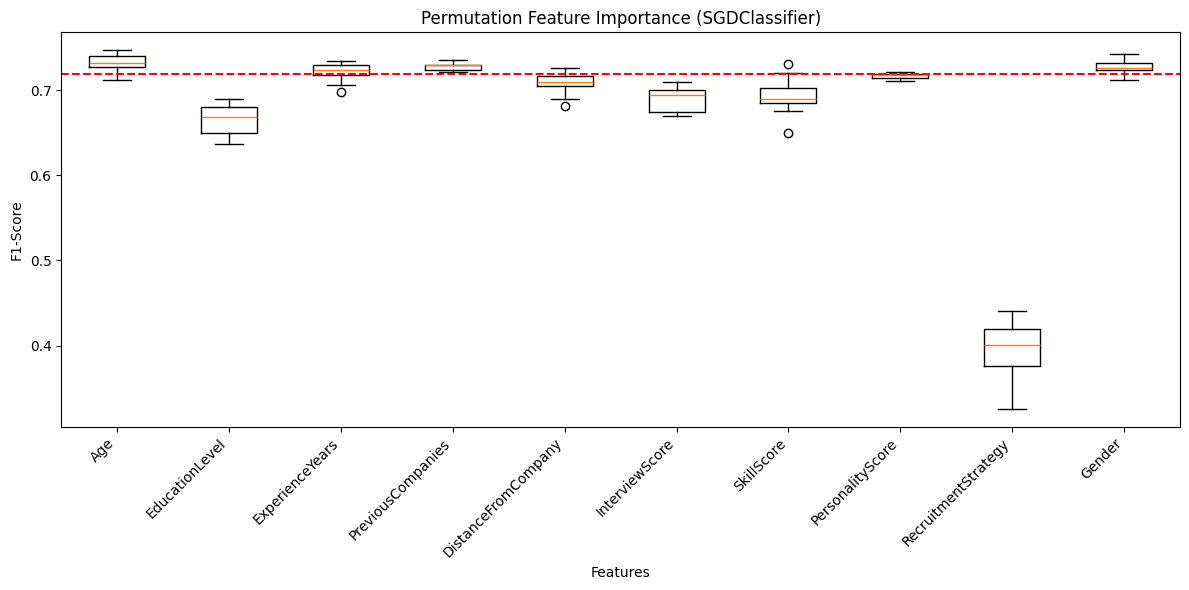

In [34]:
import matplotlib.pyplot as plt

# Boxplot visualization
plt.figure(figsize=(12, 6))
plt.boxplot(f1_scores, tick_labels=feature_names)
plt.title('Permutation Feature Importance (SGDClassifier)')
plt.xlabel('Features')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.axhline(y=f1_origin, color='r', linestyle='--', label='Baseline (Full Dataset F1-score)')
plt.show()

In [35]:
model.feature_names_in_

array(['Age', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies',
       'DistanceFromCompany', 'InterviewScore', 'SkillScore',
       'PersonalityScore', 'RecruitmentStrategy', 'Gender'], dtype=object)

## Es. 6

In [36]:
f1_fulldataset = metrics.f1_score(y_test, model.predict(X_test))

In [37]:
f1_features = {}

for feature in feature_names:
    model.fit(X_train.drop(feature, axis=1), y_train)
    f1_features[feature] = metrics.f1_score(y_test, model.predict(X_test.drop(feature, axis=1)))

f1_features

{'Age': 0.7381974248927039,
 'EducationLevel': 0.6893617021276596,
 'ExperienceYears': 0.744,
 'PreviousCompanies': 0.7542372881355932,
 'DistanceFromCompany': 0.6846153846153846,
 'InterviewScore': 0.5664739884393064,
 'SkillScore': 0.6695652173913044,
 'PersonalityScore': 0.717948717948718,
 'RecruitmentStrategy': 0.3958333333333333,
 'Gender': 0.6987951807228916}

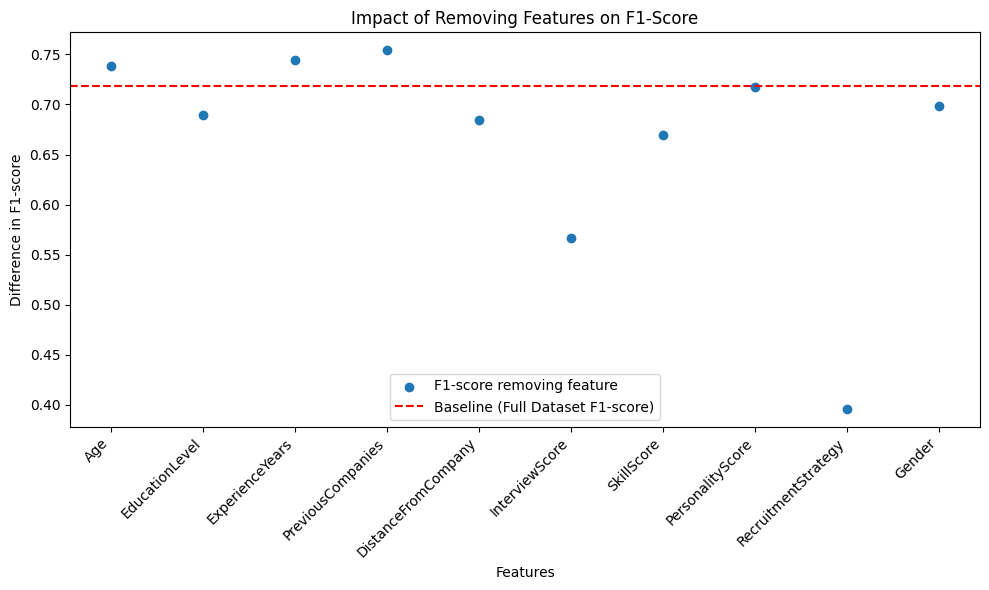

In [38]:
# plot
features = list(f1_features.keys())
f1_drops = list(f1_features.values())

plt.figure(figsize=(10, 6))
plt.scatter(features, f1_drops, label='F1-score removing feature')
plt.axhline(y=f1_fulldataset, color='r', linestyle='--', label='Baseline (Full Dataset F1-score)')

plt.xlabel("Features")
plt.ylabel("Difference in F1-score")
plt.title("Impact of Removing Features on F1-Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc='lower center')
plt.tight_layout()
plt.show()